In [1]:
import os
import sys

print(os.getcwd())
# 1. Navigate UP two levels to the project root:
#    preparation/ -> CST-Part-II-Project-Code/
os.chdir('..') # Go up one level (out of preparation)

# 2. Check the path again. We should now be in the project root.
#    You don't need to go up another level, as the previous failed attempt
#    must have been a result of not resetting the environment first.
#    We will confirm and then add the current directory ('.').

# 3. Add the project root (the directory containing 'src') to sys.path
#    The '.' refers to the Current Working Directory, which is now the project root.
if '.' not in sys.path:
    sys.path.append('.')

# Check the final working directory (optional, but helpful for confirmation)
print(f"New CWD for imports: {os.getcwd()}")
print("System path successfully configured.")

c:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code\preparation
New CWD for imports: c:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code
System path successfully configured.


In [2]:
%pip install stim
%pip install svgwrite

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from src.color_code_simulator.color_code_circuits.color_code_circuit_666 import ColorCodeCircuit666

In [4]:
circ = ColorCodeCircuit666(3,1)
layout = circ.generate_layout()

0 0
2 0
4 0
6 0
1 1
3 1
5 1
2 2
4 2
3 3


In [7]:
from dataclasses import dataclass
import stim
@dataclass
class ColorCodeTile:
    qubits: list
    ancilla: tuple
    color: str
class ColorCodeCircuit666:
    def within_bounds(self,x,y,side):
        if y<0:
            return False
        if x<y:
            return False
        if y>(side-1)-x:
            return False
        return True
        
    def generate_layout(self, distance:int):
        side = distance*3 - 2
        xtype = [['D', 'D', 'M'], ['M','D','D'], ['D','M','D']]
        dirs = [(-1,-1), (1,-1),(2,0),(1,1),(-1,1),(-2,0)]
        tiles = []
        validpos = set()
        for y in range(0, side):
            xpattern = xtype[y % 3]
            patternptr = 0
            for x in range(y,side-y,2):
                print(x,y)
                currtype = xpattern[patternptr % 3]
                if currtype == 'M':
                    tile = ColorCodeTile(
                        qubits = [(x+dx, y+dy) for dx,dy in dirs if self.within_bounds(x+dx,y+dy,side)],
                        ancilla = (x,y),
                        color = ['red','green','blue'][y % 3])
                    tiles.append(tile)
                patternptr += 1
        return tiles

    # based on https://github.com/quantumlib/chromobius/blob/main/doc/getting_started.ipynb
    def build_chrom_circuit(self, rounds:int, distance:int, after_clifford_depolarization:float, observable_basis=str):
       
        def mpp_targets(qubits:list, basis:str):
            target_basis = {'X':stim.target_x, 'Z':stim.target_z}[basis]
            idxs = sorted(qa_index_map[q] for q in qubits)
            targets = []
            for i in idxs:
                targets.append(target_basis(i))
                targets.append(stim.target_combiner())
            targets.pop()  # remove last combiner
            return targets
        def measure_observables():
            c = stim.Circuit()
            c.append("MPP", mpp_targets(sorted(qubits), observable_basis))
            c.append("OBSERVABLE_INCLUDE", stim.target_rec(-1), 0)
            return c
        def measure_stabilizers():
            c = stim.Circuit()

            for basis in ['X','Z']:
                for tile in tiles:
                    c.append("MPP", mpp_targets(tile.qubits, basis))
            
            num_stabilizers = len(tiles)*2
            for xz in range(2):
                for k, tile in enumerate(tiles):
                    ancilla  = tile.ancilla
                    chrom_color = {'red':0,'green':1,'blue':2}[tile.color]
                    chrom_annotation = chrom_color + 3*xz
                    offset = xz*len(tiles) + k
                    c.append("DETECTOR", [stim.target_rec(-(num_stabilizers - offset)), 
                                           stim.target_rec(-num_stabilizers*2+offset)],
                                           [ancilla[0], ancilla[1], 0, chrom_annotation])
            c.append("SHIFT_COORDS", [], [0,0,1])
            c.append("TICK")
            
            return c
        
        tiles = self.generate_layout(distance)
        
        qubits = {q for tile in tiles for q in tile.qubits}
        ancillae = {tile.ancilla for tile in tiles}
        sorted_q_a = sorted(qubits | ancillae)
        qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
        color_tiles = {'red':[tile for tile in tiles if tile.color=='red'],
                       'green':[tile for tile in tiles if tile.color=='green'],
                       'blue':[tile for tile in tiles if tile.color=="blue"]
                       }
        circuit = stim.Circuit()

        for q in qubits:
            idx = qa_index_map[q]
            circuit.append("QUBIT_COORDS", [idx], [q[0], q[1]])

        circuit += measure_observables()
        circuit += measure_stabilizers()
        circuit += (rounds-1) * measure_stabilizers()
        circuit += measure_stabilizers()
        circuit += measure_observables()

        return circuit


    def measure_stabilizers(self, circuit:stim.Circuit, color:str, color_tiles:dict, qa_index_map:dict, basis:str):
        tilelist = color_tiles[color]
        ancilla_idxs = [qa_index_map[tile.ancilla] for tile in tilelist]

        #reset
        circuit.append("R", ancilla_idxs)
        circuit.append("TICK")
        # prepare ancilla qubits in the correct basis
        if basis == 'X':
            circuit.append("H", ancilla_idxs)
            circuit.append("TICK")

        cnot_ops = []
        for tile in tilelist:
            ancilla_idx = qa_index_map[tile.ancilla]
            for q in tile.qubits:
                data_idx = qa_index_map[q]
                if basis == 'X':
                    cnot_ops.extend([ancilla_idx, data_idx])
                else:
                    cnot_ops.extend([data_idx, ancilla_idx])
        if cnot_ops:
            circuit.append("CNOT", cnot_ops)
            circuit.append("TICK")
        
        #measurement
        circuit.append("M", ancilla_idxs)

        return ancilla_idxs

    def measure_rounds(self, circuit:stim.Circuit, color_tiles:dict, qa_index_map:dict, measures_per_round:int):
        current_measure = 0
        loop = stim.Circuit()
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}

        for color, tilelist in color_tiles.items():
            ancilla_idxs = self.measure_stabilizers(loop, color, color_tiles, qa_index_map, basis='X')

            for i,tile in enumerate(tilelist):
                rec1 = stim.target_rec(-(len(ancilla_idxs)-i))
                rec2 = stim.target_rec(-(len(ancilla_idxs)-i+measures_per_round))

                loop.append("DETECTOR", [rec1, rec2], [tile.ancilla[0], tile.ancilla[1], 'X', chrom_annot[color]['X']])
            current_measure += len(ancilla_idxs)
            loop.append("TICK")

            # Z basis 
            ancilla_idxs = self.measure_stabilizers(loop, color, color_tiles, qa_index_map, basis='Z')

            for i,tile in enumerate(tilelist):
                rec1 = stim.target_rec(-(len(ancilla_idxs)-i))
                rec2 = stim.target_rec(-(len(ancilla_idxs)-i+measures_per_round))

                loop.append("DETECTOR", [rec1, rec2], [tile.ancilla[0], tile.ancilla[1], 'Z', chrom_annot[color]['Z']])
            current_measure += len(ancilla_idxs)
            loop.append("TICK")
            
        return loop

    def build_circuit(self, rounds:int, distance:int, after_clifford_depolarization:float):
        tiles = self.generate_layout(distance)
        circ = stim.Circuit()

        qubits = {q for tile in tiles for q in tile.qubits}
        ancillae = {tile.ancilla for tile in tiles}
        sorted_q_a = sorted(qubits | ancillae)
        qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
        color_tiles = {'red':[tile for tile in tiles if tile.color=='red'],
                       'green':[tile for tile in tiles if tile.color=='green'],
                       'blue':[tile for tile in tiles if tile.color=="blue"]
                       }
        colors = ['red','green','blue']

        # round 0:
        for c in colors:
            self.measure_stabilizers(circ, c, color_tiles, qa_index_map, basis='X')
        for c in colors:
            self.measure_stabilizers(circ, c, color_tiles, qa_index_map, basis='Z')
        # append coords to the circuit
        for q,i in qa_index_map.items():
            circ.append("QUBIT_COORDS", [i], [q[0], q[1]])

        circ.append("TICK")

        circ += (rounds-1) * self.measure_rounds(circ, color_tiles, qa_index_map, measures_per_round=2*len(tiles))

        #last round
        final_round = stim.Circuit()
        for c in colors:
            self.measure_stabilizers(final_round, c, color_tiles, qa_index_map, basis='X')
        for c in colors:
            self.measure_stabilizers(final_round, c, color_tiles, qa_index_map, basis='Z')

        circ += final_round

        #measure all qubits at the end

        return circ
circ = ColorCodeCircuit666()
layout = circ.generate_layout(3)
#circ.build_circuit(2,3,0.001)
circ.build_chrom_circuit(7,5,0.001,'X')
print(circ.build_chrom_circuit(7,5,0.001,'X').decomposed())

0 0
2 0
4 0
6 0
1 1
3 1
5 1
2 2
4 2
3 3
0 0
2 0
4 0
6 0
8 0
10 0
12 0
1 1
3 1
5 1
7 1
9 1
11 1
2 2
4 2
6 2
8 2
10 2
3 3
5 3
7 3
9 3
4 4
6 4
8 4
5 5
7 5
6 6
0 0
2 0
4 0
6 0
8 0
10 0
12 0
1 1
3 1
5 1
7 1
9 1
11 1
2 2
4 2
6 2
8 2
10 2
3 3
5 3
7 3
9 3
4 4
6 4
8 4
5 5
7 5
6 6
QUBIT_COORDS(3, 1) 4
QUBIT_COORDS(5, 1) 9
QUBIT_COORDS(8, 0) 19
QUBIT_COORDS(2, 2) 3
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(12, 0) 27
QUBIT_COORDS(3, 3) 5
QUBIT_COORDS(5, 3) 10
QUBIT_COORDS(8, 2) 20
QUBIT_COORDS(9, 1) 22
QUBIT_COORDS(11, 1) 26
QUBIT_COORDS(6, 4) 14
QUBIT_COORDS(5, 5) 11
QUBIT_COORDS(8, 4) 21
QUBIT_COORDS(9, 3) 23
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(6, 0) 12
QUBIT_COORDS(6, 6) 15
H 0 2 3 4 5 9 10 11 12 13 14 15 19 20 21 22 23 26 27
CX 2 0 3 0 4 0 5 0 9 0 10 0 11 0 12 0 13 0 14 0 15 0 19 0 20 0 21 0 22 0 23 0 26 0 27 0
M 0
CX 2 0 3 0 4 0 5 0 9 0 10 0 11 0 12 0 13 0 14 0 15 0 19 0 20 0 21 0 22 0 23 0 26 0 27 0
H 0 2 3 4 5 9 10 11 12 13 14 15 19 20 21 22 23 26 27
OBSERVABLE_INCLUDE(0) rec[-1

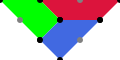

In [6]:
import svgwrite
from IPython.display import SVG, display
color_map = {
    'red':'crimson',
    'green':'lime',
    'blue':'royalblue'
    }

def draw_tiles(tiles):
    width = max(x for tile in tiles for x,y in tile.qubits)
    height = max(y for tile in tiles for x,y in tile.qubits)
    drawing = svgwrite.Drawing(size = (width*20, height*20))

    for tile in tiles:
        drawing.add(drawing.polygon(
            points = [(x*20, y*20) for x,y in tile.qubits],
            fill = color_map[tile.color]
        ))
        drawing.add(drawing.circle(center=(tile.ancilla[0]*20, tile.ancilla[1]*20), r=3, fill='grey'))
        for x,y in tile.qubits:
            drawing.add(drawing.circle(center=(x*20, y*20), r=3, fill='black'))
    
    svg_data = drawing.tostring()
    display(SVG(svg_data))

draw_tiles(layout)

In [7]:

circuit = stim.Circuit.generated(
      "color_code:memory_xyz",
      rounds=2,
      distance=3,
      after_clifford_depolarization=1e-3
)
print(str(circuit))

QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(0.5, 1) 4
QUBIT_COORDS(1.5, 1) 5
QUBIT_COORDS(2.5, 1) 6
QUBIT_COORDS(1, 2) 7
QUBIT_COORDS(2, 2) 8
QUBIT_COORDS(1.5, 3) 9
R 0 1 2 3 4 5 6 7 8 9
REPEAT 2 {
    TICK
    C_XYZ 0 1 3 5 6 7 9
    DEPOLARIZE1(0.001) 0 1 3 5 6 7 9
    TICK
    CX 5 4 3 2
    DEPOLARIZE2(0.001) 5 4 3 2
    TICK
    CX 7 4 6 2
    DEPOLARIZE2(0.001) 7 4 6 2
    TICK
    CX 1 4 6 8
    DEPOLARIZE2(0.001) 1 4 6 8
    TICK
    CX 1 2 7 8
    DEPOLARIZE2(0.001) 1 2 7 8
    TICK
    CX 5 2 9 8
    DEPOLARIZE2(0.001) 5 2 9 8
    TICK
    CX 0 4 5 8
    DEPOLARIZE2(0.001) 0 4 5 8
    TICK
    MR 2 4 8
}
DETECTOR(2, 0, 0) rec[-3] rec[-6]
DETECTOR(0.5, 1, 0) rec[-2] rec[-5]
DETECTOR(2, 2, 0) rec[-1] rec[-4]
MY 0 1 3 5 6 7 9
DETECTOR(2, 0, 1) rec[-3] rec[-4] rec[-5] rec[-6] rec[-10] rec[-13]
DETECTOR(0.5, 1, 1) rec[-2] rec[-4] rec[-6] rec[-7] rec[-9] rec[-12]
DETECTOR(2, 2, 1) rec[-1] rec[-2] rec[-3] rec[-4] rec[-8] rec[-11]


In [8]:
circuit = stim.Circuit.generated(
      "color_code:memory_xyz",
      rounds=2,
      distance=5,
      after_clifford_depolarization=1e-3
)
print(str(circuit))

QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(5, 0) 5
QUBIT_COORDS(6, 0) 6
QUBIT_COORDS(0.5, 1) 7
QUBIT_COORDS(1.5, 1) 8
QUBIT_COORDS(2.5, 1) 9
QUBIT_COORDS(3.5, 1) 10
QUBIT_COORDS(4.5, 1) 11
QUBIT_COORDS(5.5, 1) 12
QUBIT_COORDS(1, 2) 13
QUBIT_COORDS(2, 2) 14
QUBIT_COORDS(3, 2) 15
QUBIT_COORDS(4, 2) 16
QUBIT_COORDS(5, 2) 17
QUBIT_COORDS(1.5, 3) 18
QUBIT_COORDS(2.5, 3) 19
QUBIT_COORDS(3.5, 3) 20
QUBIT_COORDS(4.5, 3) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
QUBIT_COORDS(2.5, 5) 25
QUBIT_COORDS(3.5, 5) 26
QUBIT_COORDS(3, 6) 27
R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
REPEAT 2 {
    TICK
    C_XYZ 0 1 3 4 6 8 9 11 12 13 15 16 18 19 21 23 24 25 27
    DEPOLARIZE1(0.001) 0 1 3 4 6 8 9 11 12 13 15 16 18 19 21 23 24 25 27
    TICK
    CX 8 7 3 2 15 14 23 22 11 10 21 20 6 5
    DEPOLARIZE2(0.001) 8 7 3 2 15 14 23 22 11 10 21 20 6 5
    TICK
    CX 13 7 9 2 19 14